15543 697
round trips ok


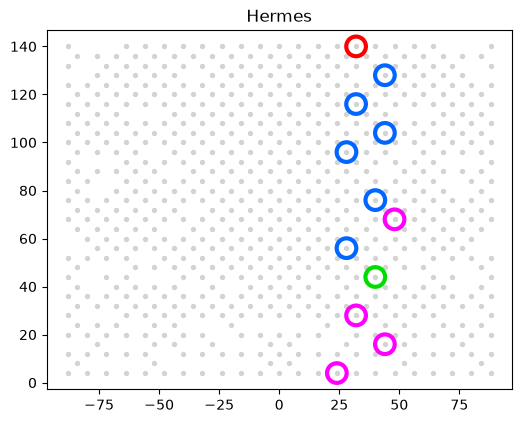

In [1]:
import sqlite3
import numpy as np
from board import *

conn = sqlite3.connect("tension.db")
holds = load_holds(conn)
data = load_data(conn)
hold_to_token, token_to_hold, VOCAB_SIZE = build_tokenizer(holds)

print(len(data), VOCAB_SIZE)

for f in data['frames']:
    assert decode(encode(f, hold_to_token), token_to_hold) == decode_frames(f)
print("round trips ok")

plot_climb(data['frames'].iloc[0], holds, data['name'].iloc[0])

In [9]:
import math
import torch
import torch.nn as nn
import torch.nn.functional as F

class AttentionHead(nn.Module):
    """One attention head. Same as before, just narrower."""
    def __init__(self, d_model, d_head):
        super().__init__()
        self.query = nn.Linear(d_model, d_head)
        self.key   = nn.Linear(d_model, d_head)
        self.value = nn.Linear(d_model, d_head)
        self.d_head = d_head

    def forward(self, x):
        q = self.query(x)
        k = self.key(x)
        v = self.value(x)

        scores = q @ k.transpose(-2, -1) / math.sqrt(self.d_head)

        T = x.shape[1]
        mask = torch.tril(torch.ones(T, T, device=x.device)).bool()
        scores = scores.masked_fill(~mask, float('-inf'))

        weights = F.softmax(scores, dim=-1)
        return weights @ v

class MultiHeadAttention(nn.Module):
    """Several heads in parallel, glued back together.

    Each head gets d_model // n_heads dimensions, so the total width is
    unchanged — you're splitting the same capacity across independent views
    rather than adding any.
    """
    def __init__(self, d_model, n_heads):
        super().__init__()
        assert d_model % n_heads == 0
        d_head = d_model // n_heads
        self.heads = nn.ModuleList(
            [AttentionHead(d_model, d_head) for _ in range(n_heads)]
        )
        self.proj = nn.Linear(d_model, d_model)   # let the heads mix

    def forward(self, x):
        out = torch.cat([h(x) for h in self.heads], dim=-1)
        return self.proj(out)

In [10]:
mha = MultiHeadAttention(d_model=128, n_heads=4)
x = torch.randn(2, 42, 128)
print(mha(x).shape)     # torch.Size([2, 42, 128])

torch.Size([2, 42, 128])


In [18]:
class Block(nn.Module):
    """One transformer layer: attention, then per-position processing.

    Attention moves information between positions. The MLP then processes each
    position on its own. Both are wrapped in residual connections, so each
    sublayer adds to the running representation rather than replacing it.
    """
    def __init__(self, d_model, n_heads):
        super().__init__()
        self.ln1 = nn.LayerNorm(d_model)
        self.attn = MultiHeadAttention(d_model, n_heads)
        self.ln2 = nn.LayerNorm(d_model)
        self.mlp = nn.Sequential(
            nn.Linear(d_model, 4 * d_model),
            nn.GELU(),
            nn.Linear(4 * d_model, d_model),
            nn.Dropout(0.1),
        )

    def forward(self, x):
        x = x + self.attn(self.ln1(x))
        x = x + self.mlp(self.ln2(x))
        return x

In [19]:
class ClimbGPT(nn.Module):
    def __init__(self, vocab_size, d_model=128, n_heads=4, n_layers=4, max_len=42):
        super().__init__()
        self.token_emb = nn.Embedding(vocab_size, d_model)   # token number -> vector
        self.pos_emb   = nn.Embedding(max_len + 1, d_model)  # position -> vector
        self.cond      = nn.Linear(2, d_model)               # (angle, grade) -> vector

        self.blocks = nn.ModuleList(
            [Block(d_model, n_heads) for _ in range(n_layers)]
        )
        self.ln_f = nn.LayerNorm(d_model)
        self.head = nn.Linear(d_model, vocab_size)           # -> score per token

    def forward(self, tokens, cond):
        # tokens: (B, T) integers.  cond: (B, 2) floats, angle and grade in 0-1.
        B, T = tokens.shape

        x = self.token_emb(tokens)                           # (B, T, d_model)

        # conditioning goes in as an extra position at the front
        c = self.cond(cond).unsqueeze(1)                      # (B, 1, d_model)
        x = torch.cat([c, x], dim=1)                          # (B, T+1, d_model)

        pos = torch.arange(T + 1, device=tokens.device)
        x = x + self.pos_emb(pos)                             # add position info

        for block in self.blocks:
            x = block(x)

        x = self.ln_f(x)
        return self.head(x)                                   # (B, T+1, vocab_size)

In [13]:
model = ClimbGPT(VOCAB_SIZE)
print(sum(p.numel() for p in model.parameters()), "parameters")
out = model(torch.randint(0, VOCAB_SIZE, (2, 42)), torch.rand(2, 2))
print(out.shape)

978361 parameters
torch.Size([2, 43, 697])


In [14]:
MAX_LEN = 2 + 2 * MAX_HOLDS

def pad(tokens):
    return tokens + [PAD] * (MAX_LEN - len(tokens))

sequences = np.array([pad(encode(f, hold_to_token)) for f in data['frames']])
angles = (data['angle'].values / 70.0).astype(np.float32)
grades = (data['difficulty_average'].values / 40.0).astype(np.float32)

from sklearn.model_selection import GroupShuffleSplit
gss = GroupShuffleSplit(n_splits=1, test_size=0.1, random_state=42)
idx_train, idx_val = next(gss.split(sequences, groups=data['uuid']))

print(sequences.shape, len(idx_train), len(idx_val))

(15543, 42) 14029 1514


In [15]:
model = ClimbGPT(VOCAB_SIZE)
opt = torch.optim.AdamW(model.parameters(), lr=3e-4)

X = torch.tensor(sequences[idx_train], dtype=torch.long)
C = torch.tensor(np.stack([angles[idx_train], grades[idx_train]], axis=1))

for epoch in range(20):
    perm = torch.randperm(len(X))
    total, nb = 0.0, 0
    for i in range(0, len(X), 64):
        batch = perm[i:i+64]
        tokens, cond = X[batch], C[batch]

        logits = model(tokens, cond)[:, :-1, :]

        loss = F.cross_entropy(
            logits.reshape(-1, VOCAB_SIZE),
            tokens.reshape(-1),
            ignore_index=PAD,
        )

        opt.zero_grad()
        loss.backward()
        opt.step()
        total += loss.item()
        nb += 1

    print(epoch, round(total / nb, 4))

0 3.3626
1 2.5378
2 2.2779
3 2.1068
4 1.9865
5 1.8887
6 1.8039
7 1.7205
8 1.6462
9 1.5707
10 1.4971
11 1.4262
12 1.3601
13 1.2979
14 1.2353
15 1.1764
16 1.124
17 1.0728
18 1.0204
19 0.9756


In [16]:
Xv = torch.tensor(sequences[idx_val], dtype=torch.long)
Cv = torch.tensor(np.stack([angles[idx_val], grades[idx_val]], axis=1))

model.eval()
with torch.no_grad():
    logits = model(Xv, Cv)[:, :-1, :]
    vl = F.cross_entropy(logits.reshape(-1, VOCAB_SIZE), Xv.reshape(-1), ignore_index=PAD)
model.train()
print("train 0.9756, val", round(vl.item(), 4))

train 0.9756, val 2.4098


In [20]:
Xv = torch.tensor(sequences[idx_val], dtype=torch.long)
Cv = torch.tensor(np.stack([angles[idx_val], grades[idx_val]], axis=1))

@torch.no_grad()
def val_loss():
    model.eval()
    logits = model(Xv, Cv)[:, :-1, :]
    l = F.cross_entropy(logits.reshape(-1, VOCAB_SIZE), Xv.reshape(-1), ignore_index=PAD)
    model.train()
    return l.item()


model = ClimbGPT(VOCAB_SIZE)
opt = torch.optim.AdamW(model.parameters(), lr=3e-4)

X = torch.tensor(sequences[idx_train], dtype=torch.long)
C = torch.tensor(np.stack([angles[idx_train], grades[idx_train]], axis=1))

best_val = float('inf')

for epoch in range(20):
    perm = torch.randperm(len(X))
    total, nb = 0.0, 0
    for i in range(0, len(X), 64):
        batch = perm[i:i+64]
        tokens, cond = X[batch], C[batch]

        logits = model(tokens, cond)[:, :-1, :]
        loss = F.cross_entropy(
            logits.reshape(-1, VOCAB_SIZE),
            tokens.reshape(-1),
            ignore_index=PAD,
        )

        opt.zero_grad()
        loss.backward()
        opt.step()
        total += loss.item()
        nb += 1

    vl = val_loss()
    if vl < best_val:
        best_val = vl
        torch.save(model.state_dict(), 'best_model.pt')
    print(epoch, round(total / nb, 4), round(vl, 4))

0 3.3544 2.6876
1 2.5081 2.398
2 2.2557 2.2272
3 2.1006 2.1429
4 1.9985 2.0911
5 1.9159 2.0525
6 1.8451 2.0413
7 1.7799 2.0316
8 1.7185 2.0355
9 1.66 2.036
10 1.6035 2.0398
11 1.5508 2.0518
12 1.4973 2.0686
13 1.447 2.0893
14 1.4012 2.1167
15 1.3533 2.1254
16 1.3109 2.1432
17 1.2687 2.1826
18 1.2261 2.2142
19 1.1902 2.2487


In [21]:
model.load_state_dict(torch.load('best_model.pt'))
print("loaded best, val:", round(best_val, 4))

loaded best, val: 2.0316


In [22]:
@torch.no_grad()
def generate(model, angle, grade, temperature=0.8, max_holds=20):
    model.eval()
    cond = torch.tensor([[angle / 70.0, grade / 40.0]], dtype=torch.float)
    tokens = torch.tensor([[BOS]], dtype=torch.long)

    used, n_start, n_finish = set(), 0, 0

    for _ in range(2 * max_holds):
        logits = model(tokens, cond)[0, -1].clone()

        expecting_role = (tokens.shape[1] % 2 == 0)

        if expecting_role:
            allowed = set(role_to_token.values())
            if n_start >= 2:
                allowed.discard(role_to_token[5])
            if n_finish >= 1:
                allowed.discard(role_to_token[7])
        else:
            allowed = set(token_to_hold.keys()) - used
            if len(used) >= 4 and n_start >= 1 and n_finish >= 1:
                allowed.add(EOS)

        mask = torch.full_like(logits, float('-inf'))
        for t in allowed:
            mask[t] = 0.0

        probs = F.softmax((logits + mask) / temperature, dim=-1)
        nxt = torch.multinomial(probs, 1).item()

        if nxt == EOS:
            break

        if nxt in token_to_hold:
            used.add(nxt)
        elif nxt == role_to_token[5]:
            n_start += 1
        elif nxt == role_to_token[7]:
            n_finish += 1

        tokens = torch.cat([tokens, torch.tensor([[nxt]])], dim=1)

    return decode(tokens[0].tolist() + [EOS], token_to_hold)

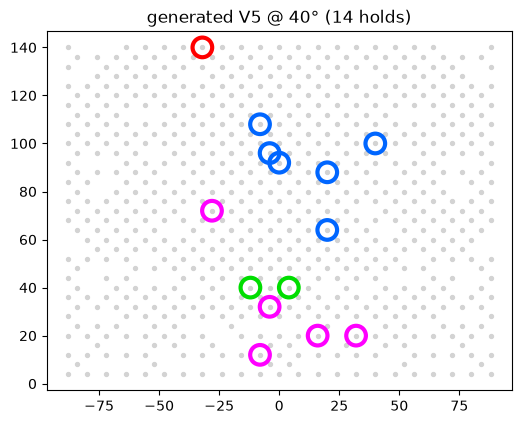

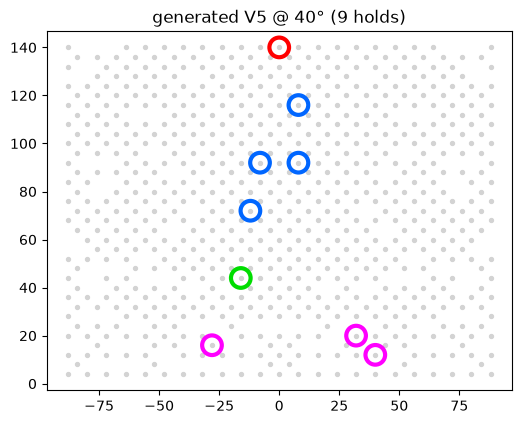

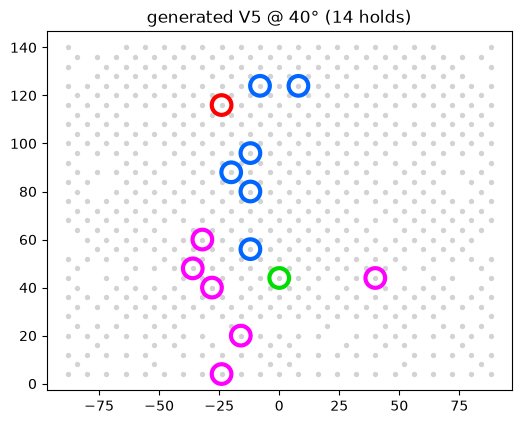

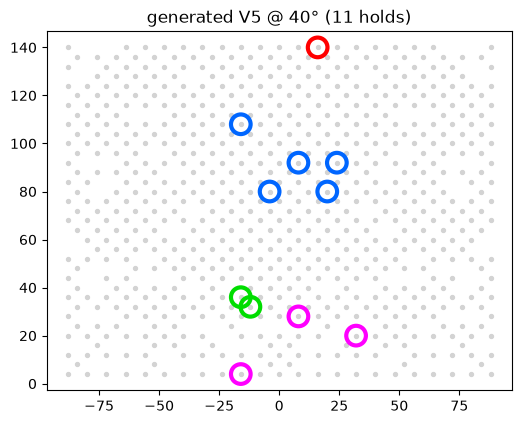

In [27]:
for i in range(4):
    climb = generate(model, angle=40, grade=20.0)
    plot_climb(climb, holds, f"generated V5 @ 40° ({len(climb)} holds)")

In [24]:
def hand_above_finish(climb, holds):
    """True if any hand/start hold sits above the finish hold."""
    coords = holds.set_index('placement_id')
    finish_ys = [coords.loc[p]['y'] for p, r in climb if r == 7]
    if not finish_ys:
        return True                      # no finish at all is also broken
    top_finish = max(finish_ys)
    other_ys = [coords.loc[p]['y'] for p, r in climb if r in (5, 6)]
    return any(y > top_finish for y in other_ys)

In [25]:
sample = data.sample(500, random_state=0)
violations = sum(hand_above_finish(decode_frames(f), holds) for f in sample['frames'])
print(f"real climbs violating: {violations}/500")

real climbs violating: 1/500


In [26]:
gen = [generate(model, angle=40, grade=20.0) for _ in range(50)]
bad = sum(hand_above_finish(c, holds) for c in gen)
print(f"generated violating: {bad}/50")

generated violating: 1/50


49 usable


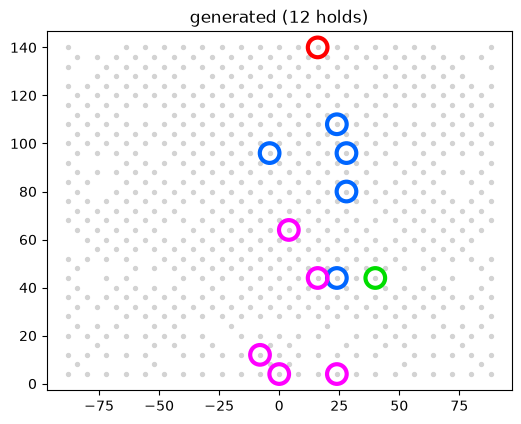

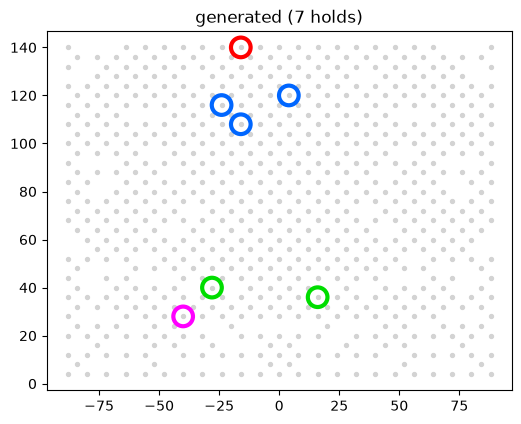

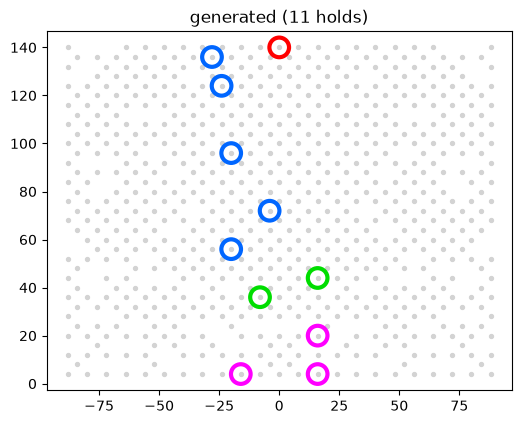

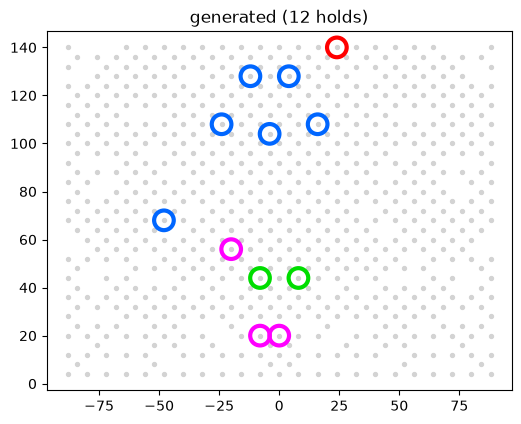

In [28]:
good = [c for c in gen if not hand_above_finish(c, holds)]
print(len(good), "usable")
for c in good[:4]:
    plot_climb(c, holds, f"generated ({len(c)} holds)")